In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, FuncFormatter
import seaborn as sns
from driver_genes.viutils import get_palette, adjust_color

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
sns.set_theme(style="ticks")

In [2]:
hue_order=['Ours', 'CellNavi', 'GEARS', 'CPA', 'DEG']
colors_sel = get_palette('benchmark').colors

In [3]:
relpos_df = pd.read_pickle('data/norman_combo_relpos_df.pkl')

In [4]:
# average relative position, the larger the better
(
    relpos_df
    .groupby('method')
    .agg(('mean', 'std'))
)

gene1               gene2          
              mean       std      mean       std
method                                          
CPA       0.751035  0.215305  0.427526  0.249479
CellNavi  0.851766  0.170098  0.582296  0.264126
DEG       0.778199  0.213272  0.456624  0.277790
GEARS     0.843619  0.195755  0.531304  0.299733
Ours      0.956294  0.111735  0.762451  0.257836

In [5]:
# average rank, the smaller the better
(
    relpos_df
    .map(lambda x: (1-x) * 105 if not hasattr(x, 'startswith') else x)
    .groupby('method')
    .agg(('mean', 'std'))
)

gene1                 gene2           
               mean        std       mean        std
method                                              
CPA       26.141313  22.607062  60.109802  26.195285
CellNavi  15.564550  17.860294  43.858901  27.733235
DEG       23.289055  22.393564  57.054439  29.167958
GEARS     16.419969  20.554261  49.213130  31.471948
Ours       4.589147  11.732205  24.942692  27.072772

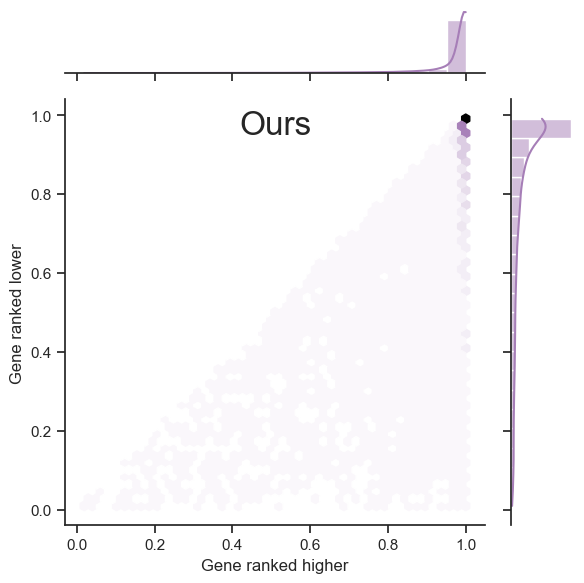

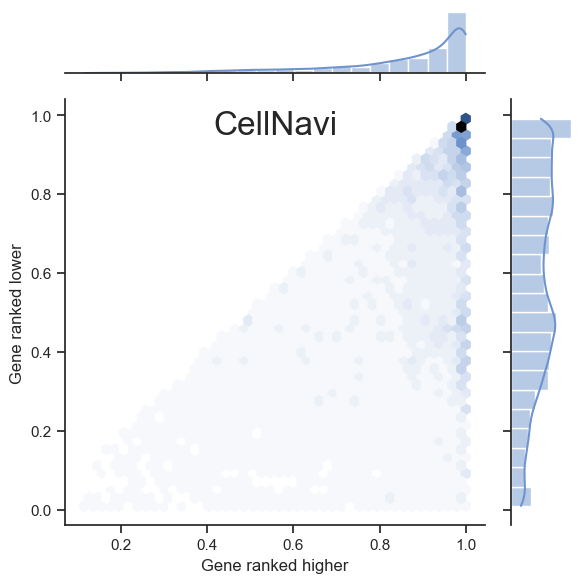

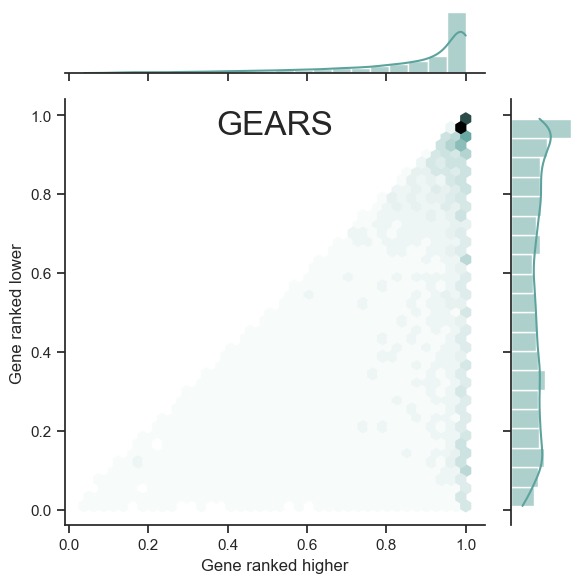

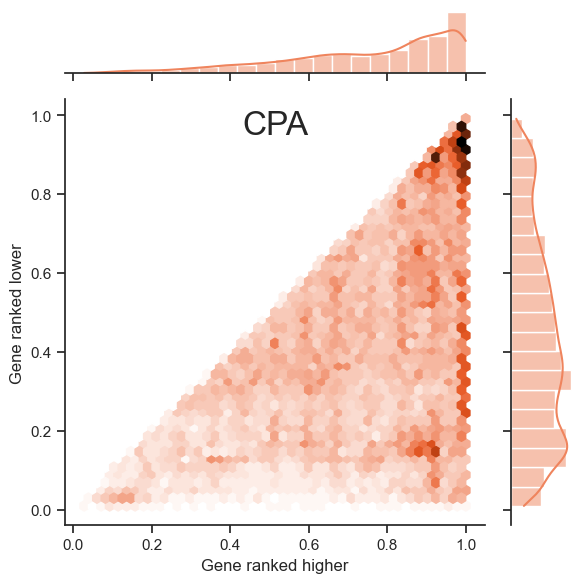

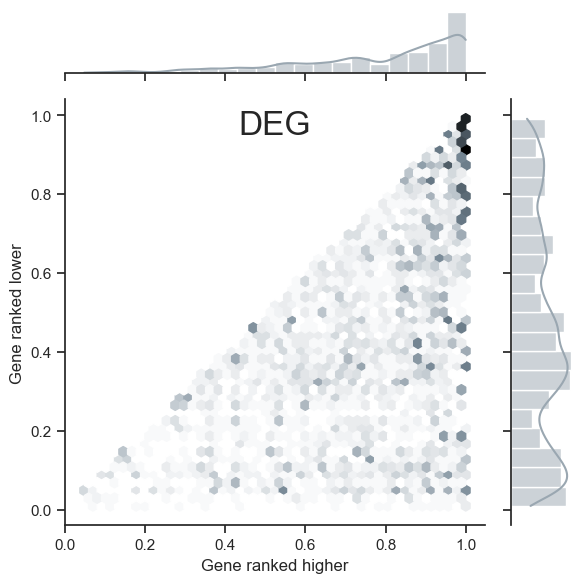

In [6]:
for i, method in enumerate(hue_order):
    ax = sns.jointplot(
        relpos_df.loc[relpos_df['method'] == method], x='gene1', y='gene2', kind='hex', 
        marginal_kws=dict(kde=True, fill=True, bins=20),
        joint_kws=dict(bins=40),
        color=colors_sel[i],
    )
    ax.set_axis_labels('Gene ranked higher', 'Gene ranked lower')
    ax.ax_joint.set_title(method, y=0.9, fontsize=24)
    plt.tight_layout()
    plt.savefig(f'../figures/2_benchmarking_norman_combo_double_relpos_{method}.pdf')
    plt.show()
